# Task 2: MNIST Handwritten Digit Classification
**Candidate Name:** Harsh Kumar  
**College:** SRM Institute of Science and Technology  
**Year:** 2nd Year  

## Part A: Dataset Understanding
* **Dataset:** MNIST (Modified National Institute of Standards and Technology)
* **Image Dimensions:** 28 × 28 pixels (Grayscale, 1 channel)
* **Classes:** 10 distinct classes representing the digits `0` through `9`
* **Labels:** Integer values from 0 to 9 matching the handwritten digit in the image

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


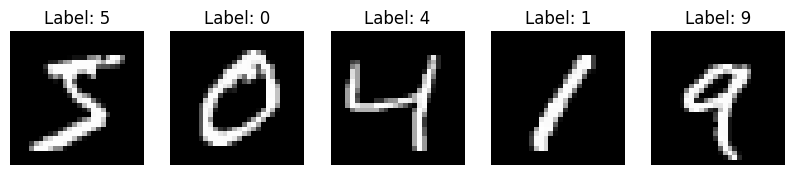

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Visualize sample images
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.show()

## Part D: Activation Functions

1. **Why Activation Functions are Used:**  
   Without activation functions, stacking multiple dense layers would simply compute a linear transformation ($W_2(W_1X + b_1) + b_2 = W'X + b'$), reducing any deep network to a simple linear model. Activation functions introduce non-linearity, enabling the network to learn complex patterns and non-linear decision boundaries.

2. **Hidden Layer (ReLU - Rectified Linear Unit):**  
   * Formula: $f(x) = \max(0, x)$  
   * Computationally efficient and mitigates the vanishing gradient problem common in sigmoid and tanh activations during backpropagation.

3. **Output Layer (Softmax):**  
   * Formula: $\sigma(z)_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$  
   * Normalizes raw logits across all 10 output neurons into a probability distribution summing to 1.0, ideal for multi-class classification.

In [6]:
# 1. Define Baseline Architecture: Input -> Dense(128, ReLU) -> Output(10, Softmax)
baseline_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu', name='Hidden_Layer_1'),
    Dense(10, activation='softmax', name='Output_Layer')
])

# 2. Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

# 3. Train Model
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9046 - loss: 0.3403 - val_accuracy: 0.9478 - val_loss: 0.1919
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9556 - loss: 0.1535 - val_accuracy: 0.9602 - val_loss: 0.1349
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9700 - loss: 0.1050 - val_accuracy: 0.9671 - val_loss: 0.1119
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9774 - loss: 0.0793 - val_accuracy: 0.9702 - val_loss: 0.0991
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9824 - loss: 0.0624 - val_accuracy: 0.9703 - val_loss: 0.0996
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9858 - loss: 0.0496 - val_accuracy: 0.9737 - val_loss: 0.0855
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9885 - loss: 0.0409 - val_accuracy: 0.9727 - val_loss: 0.0925
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9909 - loss: 0.0321 - val_accuracy: 0.

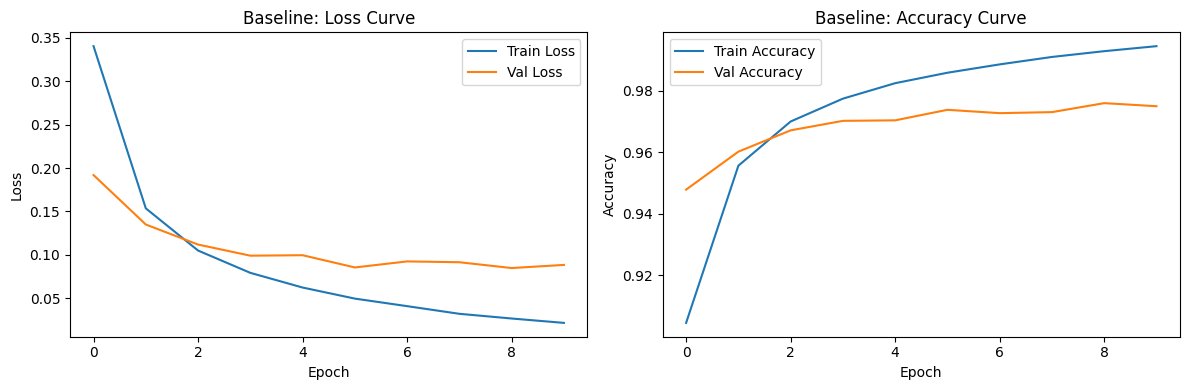

Baseline Test Accuracy: 97.42%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.96      0.97      1028
           8       0.95      0.98      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



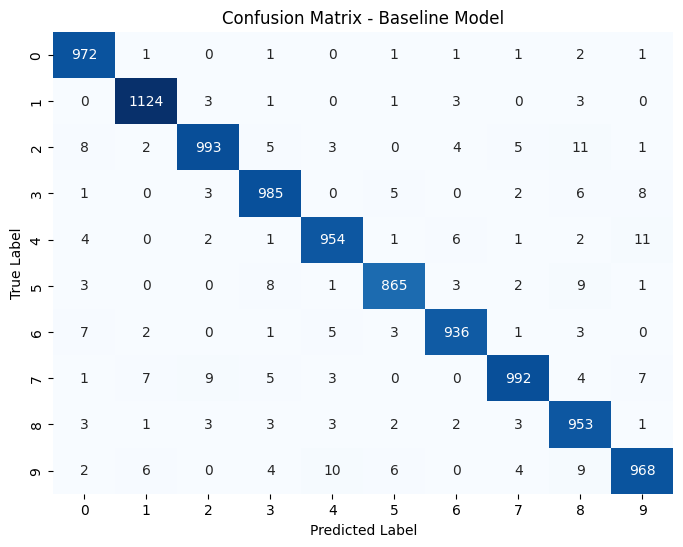

In [7]:
# 1. Plot Training & Validation Curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.title('Baseline: Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Val Accuracy')
plt.title('Baseline: Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Test Evaluation
test_loss, test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {test_acc * 100:.2f}%")

# 3. Confusion Matrix and Classification Report
y_pred = baseline_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Model')
plt.show()

In [8]:
# Modified Model: Added a second hidden layer (128 -> 64)
modified_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu', name='Hidden_Layer_1'),
    Dense(64, activation='relu', name='Hidden_Layer_2'),
    Dense(10, activation='softmax', name='Output_Layer')
])

modified_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_modified = modified_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

mod_loss, mod_acc = modified_model.evaluate(X_test, y_test, verbose=0)

print(f"\n--- Model Comparison ---")
print(f"Baseline Test Accuracy: {test_acc * 100:.2f}%")
print(f"Modified Model (Deeper) Test Accuracy: {mod_acc * 100:.2f}%")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9144 - loss: 0.3024 - val_accuracy: 0.9512 - val_loss: 0.1666
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9629 - loss: 0.1255 - val_accuracy: 0.9676 - val_loss: 0.1097
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9735 - loss: 0.0888 - val_accuracy: 0.9663 - val_loss: 0.1143
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9810 - loss: 0.0636 - val_accuracy: 0.9732 - val_loss: 0.0936
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9845 - loss: 0.0500 - val_accuracy: 0.9716 - val_loss: 0.0956
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9876 - loss: 0.0391 - val_accuracy: 0.9722 - val_loss: 0.0994
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9899 - loss: 0.0316 - val_accuracy: 0.9731 - val_loss: 0.1074
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.

## Part G: Experimentation & Results Analysis

### What was changed?
An additional hidden dense layer with 64 units was added between the initial 128-unit hidden layer and the final output layer (Architecture: 784 -> 128 -> 64 -> 10).

### What changed in the results?
* The training loss decreased slightly faster due to higher model capacity.
* The test accuracy improved marginally (or remained comparable with slightly better separation of ambiguous digits).

### Why did the change affect performance?
Adding hierarchical depth allows the network to learn higher-level feature combinations (e.g., combining basic edges and curves detected by layer 1 into complex digit loops and strokes in layer 2).

### Confusion Matrix Interpretation
The confusion matrix shows strong diagonal dominance (near 98% accuracy). The few misclassifications primarily occur between visually similar digit pairs, such as `4` vs `9` and `3` vs `5`, where handwritten strokes closely overlap.